In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
def project_and_calc_dist(X,Y,theta,p):
    x_proj = np.dot(X, theta.T)
    y_proj = np.dot(Y, theta.T)
    qs = np.linspace(0,1,100)
    xp_quantiles = np.quantile(x_proj, qs, axis=0, method="inverted_cdf")
    yp_quantiles = np.quantile(y_proj, qs, axis=0, method="inverted_cdf")
    dist_p = np.abs(xp_quantiles - yp_quantiles)**p
    return dist_p


def sample_theta(X,num_smaples=10):
    _ , d = X.shape
    theta = np.random.randn(num_smaples,d)
    theta_norm = np.linalg.norm(theta, axis=1)
    theta_normed = theta / theta_norm[:, np.newaxis]
    return theta_normed


def mom_estimates(X):
    mean_X = np.mean(X)
    var_X = np.var(X, ddof=1)
    alpha_hat = mean_X**2 / var_X
    beta_hat = mean_X/var_X
    return alpha_hat, beta_hat


In [3]:
data = pd.read_csv("DATA.csv")

X = data.iloc[:200,1:]
Y = data.iloc[300:500,1:]

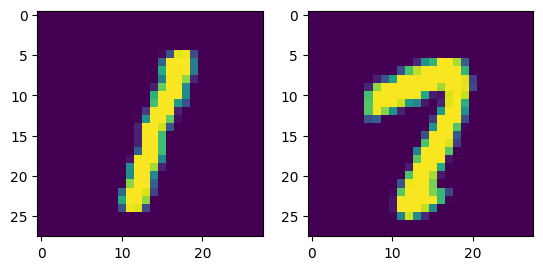

In [4]:
fig1,ax = plt.subplots(1,2)
ax[0].imshow(X.iloc[199,:].to_numpy().reshape(28,28))
ax[1].imshow(Y.iloc[199,:].to_numpy().reshape(28,28));

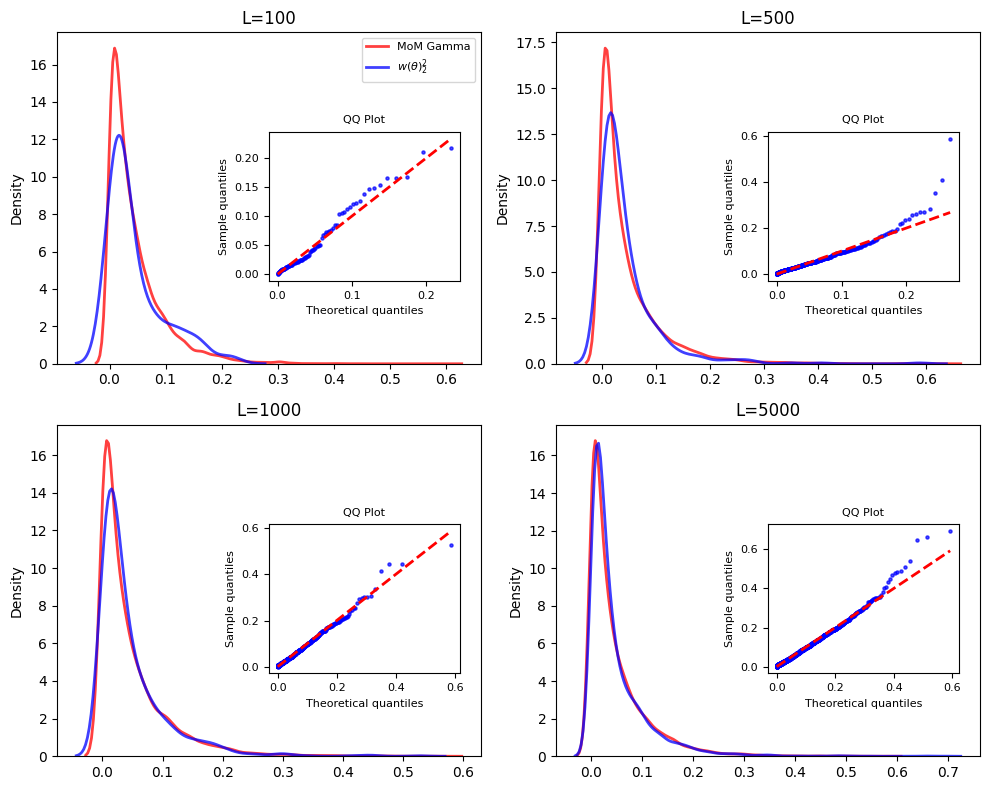

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8)) 
row = 0  

for idx, N in enumerate([100, 500, 1000, 5000]):
    THETA = sample_theta(X, N)
    w2 = project_and_calc_dist(X, Y, THETA, 2).mean(axis=0)
    
    a_hat, b_hat = mom_estimates(w2)
    
    grid_row, grid_col = divmod(idx, 2)  
    
    ax[grid_row, grid_col].set_title(f'L={N}')
    sns.kdeplot(np.random.gamma(a_hat, 1 / b_hat, 10000), ax=ax[grid_row, grid_col], lw=2, color='red', alpha=0.75, label='MoM Gamma')
    sns.kdeplot(w2, color='blue', ax=ax[grid_row, grid_col], lw=2, alpha=0.75, label='$w(\\theta)_{2}^{2}$')
    
    w2_sorted = np.sort(w2)
    start_quantile = 0.001 if N >= 1000 else 0.01
    end_quantile = 0.9999 if N >= 1000 else 0.99
    theoretical_quantiles = stats.gamma.ppf(
        np.linspace(start_quantile, end_quantile, len(w2_sorted)), a=a_hat, scale=1 / b_hat
    )
    
    inset_ax = ax[grid_row, grid_col].inset_axes([0.5, 0.25, 0.45, 0.45])  
    inset_ax.scatter(theoretical_quantiles, w2_sorted, alpha=0.7, color='blue', s=5, label='QQ Data')
    inset_ax.plot(theoretical_quantiles, theoretical_quantiles, color='red', linestyle='--', lw=2)
    inset_ax.set_title("QQ Plot",fontsize=8)
    inset_ax.set_ylabel('Sample quantiles',fontsize=8)
    inset_ax.set_xlabel('Theoretical quantiles',fontsize=8)
    inset_ax.tick_params(labelsize=8)
    
    
    if idx == 0:
        ax[grid_row, grid_col].legend(fontsize=8,loc='upper right')

fig.tight_layout()
plt.show()


In [32]:
fig.savefig('GoF_Gamma_MNIST.pdf')

<Axes: >

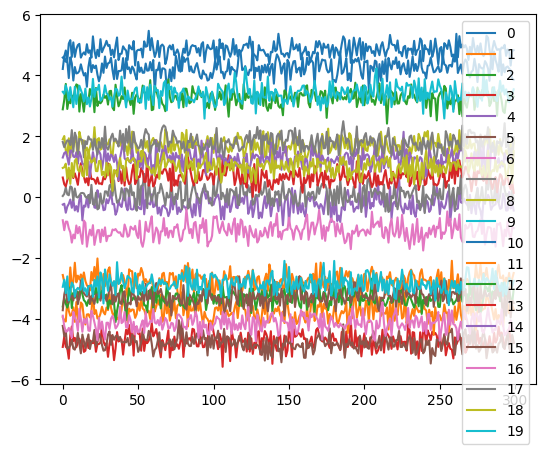

In [14]:
def make_dynamic_blobs(n_samples, base_center, n_clusters, varying_features, 
                       cluster_std=1.0, center_offset_range=(-5, 5), random_state=None):
    """
    Generate synthetic data with dynamic centers based on a base center and random offsets.
    
    Parameters:
        n_samples: int
            Total number of samples.
        base_center: array-like
            The center of the first cluster. Shape: (n_features,).
        n_clusters: int
            Number of clusters to generate.
        varying_features: list of int
            Indices of features that should vary across clusters.
        cluster_std: float
            Standard deviation of clusters.
        center_offset_range: tuple
            Range (min, max) for random uniform offsets added to the base center for varying features.
        random_state: int or None
            Random seed for reproducibility.
    
    Returns:
        X: ndarray of shape (n_samples, n_features)
            The generated samples.
        y: ndarray of shape (n_samples,)
            The integer labels for cluster membership.
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    n_features = len(base_center)
    samples_per_cluster = n_samples // n_clusters
    remainder = n_samples % n_clusters

    # Generate cluster centers
    centers = [np.array(base_center,dtype=float)]
    for _ in range(1, n_clusters):
        new_center = centers[0].copy()  # Start with the base center
        for feature in varying_features:
        
            new_center[feature] +=  np.random.uniform(*center_offset_range)
            print(new_center[feature])
            
        centers.append(new_center)
    centers = np.array(centers)
    
    # Generate points for each cluster
    X = []
    y = []
    for cluster_idx, center in enumerate(centers):
        cluster_size = samples_per_cluster + (1 if cluster_idx < remainder else 0)
        cluster_points = np.random.normal(
            loc=center,
            scale=cluster_std,
            size=(cluster_size, n_features)
        )
        X.append(cluster_points)
        y.extend([cluster_idx] * cluster_size)
    
    X = np.vstack(X)
    y = np.array(y)
    
    return X.astype(np.float32), y, centers

# Example Usage
base_centerX = list(np.random.uniform(-5,5,20))#,0,0,0,0]  # Base center for the first cluster
n_clusters = 1
n_samples = 300
varying_features = [0,5,3]#[0,5,3]#, 1,4,5,6]  # Only the first two features vary
X, y, centers = make_dynamic_blobs(
    n_samples=n_samples, 
    base_center=base_centerX, 
    n_clusters=n_clusters, 
    varying_features=varying_features, 
    cluster_std=0.25, 
    center_offset_range=(-0.5, 0.5), 
    random_state=2025
)
base_centerY = list(np.random.uniform(-3,3,20))#,0,0,0,0]  # Base center for the first cluster

Y, y, centers = make_dynamic_blobs(
    n_samples=n_samples, 
    base_center=base_centerY, 
    n_clusters=n_clusters, 
    varying_features=varying_features, 
    cluster_std=0.25, 
    center_offset_range=(-0.5, 0.5), 
    random_state=2020
)

fig, ax = plt.subplots()
pd.DataFrame(X).plot(ax=ax,legend=True)

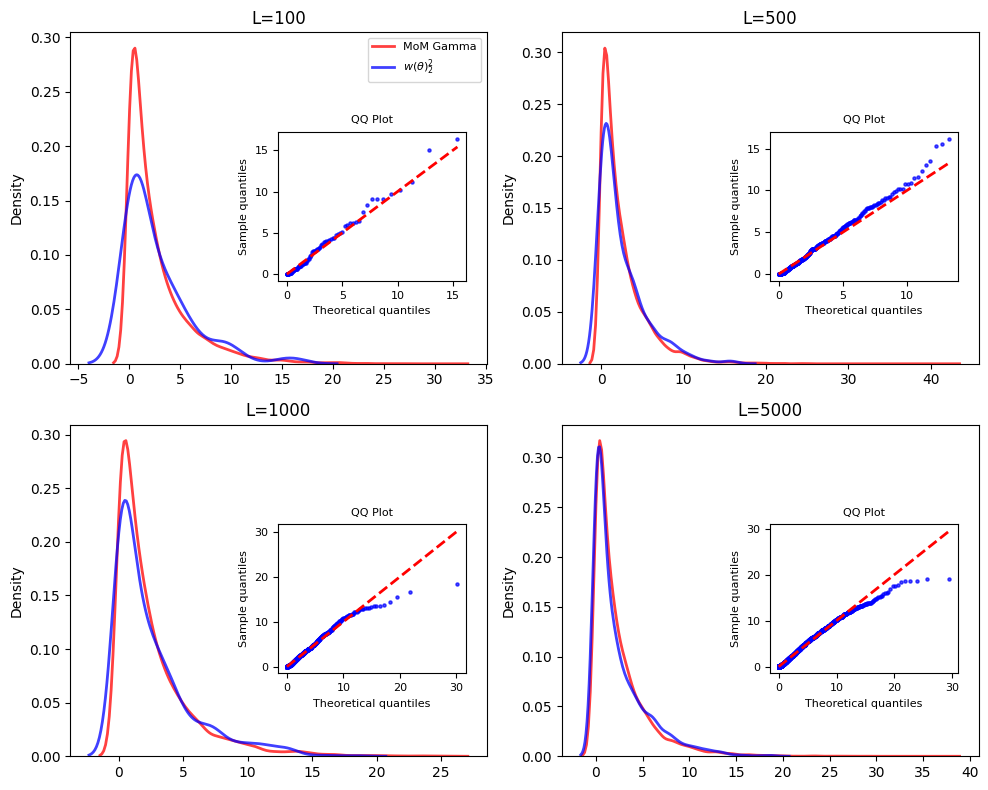

In [38]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8)) 
row = 0  

for idx, N in enumerate([100, 500, 1000, 5000]):
    THETA = sample_theta(X, N)
    w2 = project_and_calc_dist(X, Y, THETA, 2).mean(axis=0)
    
    a_hat, b_hat = mom_estimates(w2)
    
    grid_row, grid_col = divmod(idx, 2)  
    
    ax[grid_row, grid_col].set_title(f'L={N}')
    sns.kdeplot(np.random.gamma(a_hat, 1 / b_hat, 10000), ax=ax[grid_row, grid_col], lw=2, color='red', alpha=0.75, label='MoM Gamma')
    sns.kdeplot(w2, color='blue', ax=ax[grid_row, grid_col], lw=2, alpha=0.75, label='$w(\\theta)_{2}^{2}$')
    
    w2_sorted = np.sort(w2)
    start_quantile = 0.001 if N >= 1000 else 0.01
    end_quantile = 0.9999 if N >= 1000 else 0.99
    theoretical_quantiles = stats.gamma.ppf(
        np.linspace(start_quantile, end_quantile, len(w2_sorted)), a=a_hat, scale=1 / b_hat
    )
    
    inset_ax = ax[grid_row, grid_col].inset_axes([0.5, 0.25, 0.45, 0.45])  
    inset_ax.scatter(theoretical_quantiles, w2_sorted, alpha=0.7, color='blue', s=5, label='QQ Data')
    inset_ax.plot(theoretical_quantiles, theoretical_quantiles, color='red', linestyle='--', lw=2)
    inset_ax.set_title("QQ Plot",fontsize=8)
    inset_ax.set_ylabel('Sample quantiles',fontsize=8)
    inset_ax.set_xlabel('Theoretical quantiles',fontsize=8)
    inset_ax.tick_params(labelsize=8)
    
    
    if idx == 0:
        ax[grid_row, grid_col].legend(fontsize=8,loc='upper right')

fig.tight_layout()
plt.show()


In [85]:
dims = [5,10,20,100,200]

out = {}

for d in dims:
    print(d)
    out[d] = []
    base_centerX = list(np.random.uniform(-3,3,d))#,0,0,0,0]  # Base center for the first cluster
    base_centerY = list(np.random.uniform(-1,1,d))#,0,0,0,0]  # Base center for the first cluster
    n_samples = 1000
    N= 500

    for trial in range(10):

        X, _, _ = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_centerX, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=0.25, 
            center_offset_range=(-0.5, 0.5), 
            random_state=trial
        )

        Y, _, _ = make_dynamic_blobs(
            n_samples=n_samples, 
            base_center=base_centerY, 
            n_clusters=n_clusters, 
            varying_features=varying_features, 
            cluster_std=0.25, 
            center_offset_range=(-0.5, 0.5), 
            random_state=2*(trial+1)
        )

        THETA = sample_theta(X, N)
        w2 = project_and_calc_dist(X, Y, THETA, 2).mean(axis=0)
        a_hat, b_hat = mom_estimates(w2)

        w2_sorted = np.sort(w2)
        start_quantile = 0.001 if N >= 1000 else 0.01
        end_quantile = 0.9999 if N >= 1000 else 0.99
        theoretical_quantiles = stats.gamma.ppf(
            np.linspace(start_quantile, end_quantile, len(w2_sorted)), a=a_hat, scale=1 / b_hat
        )

        out[d].append(np.abs(w2_sorted-theoretical_quantiles).mean())

        

5
10
20
100
200


In [86]:
#L=100

for d in dims:
    print(f"d = {d} with MAP: {np.mean(out[d]):.4f} +- {np.std(out[d]):.4f}")

d = 5 with MAP: 1.1226 +- 0.1722
d = 10 with MAP: 0.3479 +- 0.0631
d = 20 with MAP: 0.4014 +- 0.0724
d = 100 with MAP: 0.2912 +- 0.0451
d = 200 with MAP: 0.2987 +- 0.0535


In [ ]:
### L =1000

for d in dims:
    print(f"d = {d} with MAP: {np.mean(out[d]):.4f} +- {np.std(out[d]):.4f}")

d = 5 with MAP: 0.3586 +- 0.0326
d = 10 with MAP: 0.3187 +- 0.0638
d = 20 with MAP: 0.1652 +- 0.0373
d = 100 with MAP: 0.1100 +- 0.0154
d = 200 with MAP: 0.1344 +- 0.0485


In [ ]:
#L =10000
for d in dims:
    print(f"d = {d} with MAP: {np.mean(out[d]):.4f} +- {np.std(out[d]):.4f}")

d = 5 with MAP: 0.3751 +- 0.0106
d = 10 with MAP: 0.1499 +- 0.0090
d = 20 with MAP: 0.1347 +- 0.0158
d = 100 with MAP: 0.0470 +- 0.0124
d = 200 with MAP: 0.0448 +- 0.0142


| Dimension ($d$) |  L=100 | L=1000 | L=10000 |
| :---: | :---: | :---: | :---: |
| 5 | $1.1226 \pm 0.1722$ | $0.3586 \pm 0.0326$ | $0.3751 \pm 0.0106$ |
| 10 | $0.3479 \pm 0.0631$ | $0.3187 \pm 0.0638$ | $0.1499 \pm 0.0090$ |
| 20 | $0.4014 \pm 0.0724$ | $0.1652 \pm 0.0373$ | $0.01347 \pm 0.0158$ |
| 100 | $0.2912 \pm 0.0451$ | $0.1100 \pm 0.0154$ | $0.0470 \pm 0.0124$ |
| 200 | $0.2987 \pm 0.0535$ | $0.1344 \pm 0.0485$ | $0.0448 \pm 0.0142$ |

